In [37]:
import pandas as pd
import numpy as np
import random, os

import gseapy as gp
from indra.sources.indra_db_rest.api import get_statements

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [38]:
# Get a list of HGNC genes from INDRA statements  
def extract_gene_evidence(statements):
    """
    This function examines all agents in each INDRA statement and
    returns the names of agents that have an HGNC database reference.
    """

    genes = set()

    for stmt in statements:
        for agent in stmt.agent_list():  

            if agent is not None and "HGNC" in agent.db_refs:
                genes.add(agent.name)

    return genes

In [39]:
# Get the union of the top N enriched pathways across all drugs
def top_pathways(df, top_n=10, alpha=0.05, min_overlap=5):
    """
    This function identifies the union of the top enriched pathways across all 
    drugs, filtering pathways by statistical significance and minimum gene overlap.
    """

    df = df.copy()

    # Filter by significance and overlap
    df = df.loc[(df["FDR"] < alpha) & (df["Gene count"] >= min_overlap)]

    # Sort by FDR first, then by overlap
    df = df.sort_values(by=["FDR", "Gene count"], ascending=[True, False])

    # Keep top N pathways for each drug
    top_pathways = set(df.groupby("Drug", group_keys=False).head(top_n)["Pathway"])
    
    return df[df.Pathway.isin(top_pathways)]

### MELANOMA

In [ ]:
# Load results
out_path = "out_data"
drug_score = pd.read_csv(os.path.join(out_path, "neg_drug_scores.csv"), index_col=0)
drug_score

,drug_score,p_val,fdr,Cluster_T_cells_genes,Cluster_DC_genes,Cluster_Keratinocytes_genes,Cluster_Neurons_genes,drug_id
digitoxin,38.345954,0.000127,0.004884,SPRR1B;TACSTD2;CST6;CDSN;SERPINB7;KLK5;DNAJB1;...,SPRR1B;GADD45A;GLS;TMEM40;SQLE;CDSN;HMGCS1;SER...,SPRR1B;TMEM40;PRSS23;MAP1LC3B;LGALS3BP;CST6;SE...,S100B;SPRR1B;PRSS23;SCAMP3;TACSTD2;TMX4;TRIB2;...,BRD-A93236127
ouabain,24.933184,0.000097,0.004324,TMEM40;SERPINB7;KLK5;HSPA8;SERPINB2;CXCL8;KLK1...,GADD45A;SEC61B;MS4A6A;GLS;TMEM40;MALT1;PLSCR1;...,LDHB;TMEM40;PRSS23;MAP1LC3B;ADH5;SERPINB7;GADD...,PRSS23;LDHB;TMEM40;SERPINB2;SERPINB7;KLK5;SPIN...,BRD-A68930007
digoxin,18.647205,0.000113,0.004680,SPRR1B;SERPINB7;SPINK5;RPS17;CPA4;PMF1;HSPA8;S...,SPRR1B;GADD45A;GLS;CD14;RNASET2;MALT1;SPINK5;P...,SPRR1B;APOD;PRSS23;MAP1LC3B;LGALS3BP;SERPINB7;...,LGALS3BP;SPRR1B;PRSS23;DUSP4;TMX4;SERPINB2;SER...,BRD-A94756469
doxorubicin,5.118103,0.008776,0.115427,NDUFB8;TMEM40;CDSN;EGLN3;SFN;CLDND1;TNFSF12;DN...,IDO1;GADD45A;FXYD5;NPC2;PLAUR;TMEM40;CPVL;NDUF...,TUBB;PMP22;SERPINE2;CCND1;IFI16;LDHB;BACE2;MGP...,S100B;SERPINE2;PRSS23;CCND1;NRN1;LDHB;DUSP4;BS...,BRD-A52530684
amsacrine,4.664213,0.001080,0.030532,SFN;HSPA8;C11orf68;CXCL8;DUSP4;CCL20;IL1RL1;EP...,GADD45A;BIRC3;TGFBI;DUSP5;IL32;SFN;ADGRE5;ENO3...,CCND1;EDNRB;BACE2;PRSS23;MAP1LC3B;PLOD3;FN1;GA...,RHOBTB3;PRSS23;CCND1;PLOD3;TUBB;SFN;PRDM1;IL1R...,BRD-K98490050
...,...,...,...,...,...,...,...,...
mexiletine,0.000000,0.999648,1.000000,IER3IP1;CKLF;TNFAIP3;EEF1E1;HIGD1A;SERPINB3;AT...,FXYD5;NPC2;ATP6V0C;CRIP1;TGFBI;HIGD1A;SFN;DUSP...,SERPINE2;GRINA;TRA2A;PHACTR4;CYB5R3;CCNL1;PAFA...,ATP6V0C;SERPINE2;GRINA;PAFAH1B3;PLD3;NPC2;ADIR...,BRD-A64092382
thiethylperazine,0.000000,0.999868,1.000000,HLA-C;PRSS22;DNAJB1;PMF1;DHRS9;PARL;EVA1B;DUSP...,BIRC3;RAB9A;TALDO1;LAMP3;KLF4;TJP1;IL32;IL1B;P...,CALD1;MGP;NNMT;CXCL14;FN1;BGN;GPM6B;SPARCL1;PS...,GPM6B;DUSP4;MIF;HLA-C;PRSS22;DHRS9;CCL20;RAB25...,BRD-K69600043
dasatinib,0.000000,1.000000,1.000000,JUN;RABAC1;VKORC1;CNPY2;ECH1;KLF6;TNFSF12;DNAJ...,RAMP1;CD68;ATP6V0C;PLAUR;CRIP1;CD44;MARCKSL1;C...,EMP3;CCND1;CXCL12;ARID5B;ACTN1;COL4A2;C20orf27...,ATP6V0C;CCND1;STMN1;C20orf27;PAFAH1B3;TUBB;PSM...,BRD-K49328571
olaparib,0.000000,0.991123,1.000000,RPS10;CSTA;SPRR1B;RPL26;PPP1R14B;SPRR2B;CHMP4A...,RAMP1;TXN;GSTP1;SPRR1B;GADD45A;CCL22;FSCN1;CCR...,SPRR1B;CSTA;APOE;CALD1;AEBP1;GPR143;BCAN;DCN;G...,GPR143;APOE;SPRR1B;FLOT1;CSTA;SCIN;AEBP1;KRT17...,BRD-K02113016


In [41]:
# Subset drugs by score and FDR
top_drugs = drug_score[drug_score["fdr"] < 0.05].sort_values("drug_score", ascending=False).head(15)
top_drugs

,drug_score,p_val,fdr,Cluster_T_cells_genes,Cluster_DC_genes,Cluster_Keratinocytes_genes,Cluster_Neurons_genes,drug_id
digitoxin,38.345954,1.273313e-04,0.004884,SPRR1B;TACSTD2;CST6;CDSN;SERPINB7;KLK5;DNAJB1;...,SPRR1B;GADD45A;GLS;TMEM40;SQLE;CDSN;HMGCS1;SER...,SPRR1B;TMEM40;PRSS23;MAP1LC3B;LGALS3BP;CST6;SE...,S100B;SPRR1B;PRSS23;SCAMP3;TACSTD2;TMX4;TRIB2;...,BRD-A93236127
ouabain,24.933184,9.662800e-05,0.004324,TMEM40;SERPINB7;KLK5;HSPA8;SERPINB2;CXCL8;KLK1...,GADD45A;SEC61B;MS4A6A;GLS;TMEM40;MALT1;PLSCR1;...,LDHB;TMEM40;PRSS23;MAP1LC3B;ADH5;SERPINB7;GADD...,PRSS23;LDHB;TMEM40;SERPINB2;SERPINB7;KLK5;SPIN...,BRD-A68930007
digoxin,18.647205,1.132928e-04,0.004680,SPRR1B;SERPINB7;SPINK5;RPS17;CPA4;PMF1;HSPA8;S...,SPRR1B;GADD45A;GLS;CD14;RNASET2;MALT1;SPINK5;P...,SPRR1B;APOD;PRSS23;MAP1LC3B;LGALS3BP;SERPINB7;...,LGALS3BP;SPRR1B;PRSS23;DUSP4;TMX4;SERPINB2;SER...,BRD-A94756469
amsacrine,4.664213,1.080284e-03,0.030532,SFN;HSPA8;C11orf68;CXCL8;DUSP4;CCL20;IL1RL1;EP...,GADD45A;BIRC3;TGFBI;DUSP5;IL32;SFN;ADGRE5;ENO3...,CCND1;EDNRB;BACE2;PRSS23;MAP1LC3B;PLOD3;FN1;GA...,RHOBTB3;PRSS23;CCND1;PLOD3;TUBB;SFN;PRDM1;IL1R...,BRD-K98490050
bortezomib,1.410627,3.117959e-08,0.000006,NR4A2;ZFP36L2;IFITM1;SLC2A3;IFITM3;CIRBP;IL36G...,CST3;IFITM3;GSTP1;GADD45A;FXYD5;PLAUR;IFITM2;N...,VIM;PMEL;IFITM3;CST3;IFITM1;TYRP1;SERPINE2;APO...,S100B;SERPINE2;EDNRB;GRINA;LGALS3BP;GSTK1;PMEL...,BRD-K88510285
albendazole,1.188020,5.288396e-06,0.000406,TACSTD2;CALML5;SERPINB7;CPA4;RBM3;KIAA0355;LMN...,GADD45A;GLS;CALML5;PLSCR1;TJP1;LILRB2;HMGCS1;S...,PMEL;TSC22D3;DCT;PRAME;COL1A2;GPR143;COL3A1;GM...,PRAME;GPR143;PMEL;DUSP4;TACSTD2;RBCK1;HIST1H2B...,BRD-K79131256
neratinib,0.797999,6.675375e-06,0.000448,C1orf56;CALML5;RBM3;HIGD1A;CLU;NMT1;CSTB;GGPS1...,GADD45A;S100A4;RAB9A;AOC1;ARHGDIB;CRIP1;SQSTM1...,SPARC;EDNRB;LDHB;PRAME;MGP;A2M;PRSS23;MAP1LC3B...,PRAME;S100B;SPARC;GRINA;PLTP;LGALS3BP;PRSS23;L...,BRD-K85606544
niclosamide,0.786672,1.420816e-08,0.000004,KRT23;TACSTD2;TMEM40;RPL26;KRT17;LCN2;CPA4;CLD...,GADD45A;BIRC3;MS4A6A;S100A4;RAB9A;ATP6V0C;SQST...,TMEM40;PRSS23;MAP1LC3B;GRINA;S100A4;TACSTD2;GA...,ATP6V0C;GRINA;ALDOA;PRSS23;STMN1;OXA1L;C20orf2...,BRD-K35960502
cladribine,0.719457,4.579717e-05,0.002236,TMEM40;RPS17;CPA4;HSPA8;SERPINB2;EPS8L1;EFNA1;...,GADD45A;CD14;SQSTM1;TMEM40;DUSP5;SAMHD1;ST20;H...,EDNRB;LDHB;TMEM40;PRSS23;PLOD3;ADH5;GADD45A;RS...,PRSS23;PLOD3;C20orf27;TMX4;TMEM40;PAFAH1B3;PRD...,BRD-K93034159
isotretinoin,0.668871,2.078849e-03,0.048537,CSTA;SPRR1B;S100A8;DUSP1;JUNB;HOPX;SERPINB7;EG...,SPRR1B;FOSB;DUSP1;S100A4;NR4A2;MARCKSL1;HOPX;C...,SPRR1B;CSTA;TYR;ZEB2;SLC2A3;PRSS23;PLOD3;S100A...,SPRR1B;PRSS23;STMN1;CSTA;DUSP4;F2R;GMPR;CRYL1;...,BRD-K76723084


In [42]:
# Get the important genes for each drug in the "Neurons" cell type
drug_important_genes = {}
for name in top_drugs.index:
    drug_important_genes[name] = set(top_drugs.loc[name]["Cluster_Neurons_genes"].split(";"))

In [ ]:
# Load background genes 
background_genes = pd.read_csv(os.path.join(out_path, "MEL_gene_list_common.csv"), sep="\t")
background_genes

,Cluster,Genes
0,T_cells,EPHB3;ESRRA;TRADD;PRPF8;CAPNS1;RPL35;RPL28;EIF...
1,DC,DDR1;PAX8;EPHB3;ESRRA;TRADD;PRPF8;CAPNS1;RPL35...
2,Keratinocytes,DDR1;PAX8;EPHB3;ESRRA;TRADD;PRPF8;CAPNS1;RPL35...
3,Neurons,DDR1;PAX8;EPHB3;ESRRA;TRADD;PRPF8;CAPNS1;RPL28...


In [44]:
background = background_genes[background_genes.Cluster == "Neurons"]["Genes"][3].split(";")
len(background)

8859

In [ ]:
# Download the Reactome gene sets from MSigDB 
reactome = gp.parser.read_gmt(os.path.join(out_path, "c2.cp.reactome.v2026.1.Hs.symbols.gmt"))

# ORA enrichment
enrichment_react = {}
gene_sets = reactome
background = list(set(background))

# Get enriched pathways for each drug
for drug in drug_important_genes.keys():
    gene_list = list(drug_important_genes[drug])
    print(drug, len(gene_list), len(set(gene_list) & set(background)))
    if len(gene_list) > 0:
        enr = gp.enrich(
            gene_list = gene_list,
            gene_sets = gene_sets,
            background = background
        )
        enrichment_react[drug] = enr.res2d.sort_values(by="Adjusted P-value").reset_index(drop=True)
    else:
        enrichment_react[drug] = None

digitoxin 146 146
ouabain 141 141
digoxin 146 146
amsacrine 137 137
bortezomib 216 216
albendazole 145 145
neratinib 305 305
niclosamide 319 319
cladribine 139 139
isotretinoin 159 159
parthenolide 245 245
panobinostat 263 263
ixazomib 165 165
ethotoin 114 114
chloroxine 142 142


In [46]:
# Extract enriched pathway information for each drug
rows = []
for drug in enrichment_react:
    enr = enrichment_react[drug]
    if enr is not None:

        for _, row in enr.iterrows():
            
            pathway_genes = set(row["Genes"].split(";"))
            pathway_name = (row["Term"].replace("REACTOME_", "").replace("_", " "))
            rows.append({
                "Drug": drug,
                "Pathway": pathway_name,
                "FDR": row["Adjusted P-value"],
                "Overlap": row["Overlap"],
                "Genes": pathway_genes,
                "Gene count": len(pathway_genes)
            })

pathway_df = pd.DataFrame(rows)
pathway_df

,Drug,Pathway,FDR,Overlap,Genes,Gene count
0,digitoxin,KERATINIZATION,0.008437,7/56,"{KRT6A, KRT31, PKP1, KLK5, SPRR1B, CDSN, KRT9}",7
1,digitoxin,FORMATION OF THE CORNIFIED ENVELOPE,0.008437,7/56,"{KRT6A, KRT31, PKP1, KLK5, SPRR1B, CDSN, KRT9}",7
2,digitoxin,DISSOLUTION OF FIBRIN CLOT,0.080565,3/10,"{PLAU, SERPINB8, SERPINB2}",3
3,digitoxin,CYCLIN A B1 B2 ASSOCIATED EVENTS DURING G2 M T...,0.133182,4/28,"{CCNB1, CDC25B, PLK1, CCNA2}",4
4,digitoxin,EGFR INTERACTS WITH PHOSPHOLIPASE C GAMMA,0.176106,2/6,"{HBEGF, PLCG1}",2
...,...,...,...,...,...,...
8962,chloroxine,PROCESSING OF CAPPED INTRON CONTAINING PRE MRNA,0.980730,1/222,{RBM7},1
8963,chloroxine,INFECTIOUS DISEASE,0.984981,8/895,"{LAMB1, HBEGF, VEGFA, HMOX1, EGFR, PRKCSH, BLN...",8
8964,chloroxine,TRANSLATION,0.988363,1/256,{OXA1L},1
8965,chloroxine,VIRAL INFECTION PATHWAYS,0.999889,4/743,"{EGFR, PRKCSH, VEGFA, BLNK}",4


In [47]:
# Keep the top 10 significantly enriched pathways for each drug
# and retain the union of these pathways across all drugs
pathway_df_filtered = top_pathways(pathway_df, top_n=10).reset_index(drop=True)
pathway_df_filtered

,Drug,Pathway,FDR,Overlap,Genes,Gene count
0,amsacrine,CELL CYCLE MITOTIC,3.118347e-13,33/396,"{CCNB2, PLK1, NCAPG2, BUB1, KIF23, TOP2A, TUBB...",33
1,amsacrine,CELL CYCLE,4.304240e-13,36/495,"{CCNB2, PLK1, NCAPG2, BUB1, KIF23, TOP2A, TUBB...",36
2,niclosamide,CELL CYCLE MITOTIC,5.887585e-13,51/396,"{GINS1, CCNB2, PLK1, BUB1, TUBB3, TYMS, MYBL2,...",51
3,cladribine,CELL CYCLE MITOTIC,2.075294e-11,31/396,"{CCNB2, PLK1, BUB1, KIF23, TOP2A, SKA1, LMNB1,...",31
4,cladribine,RESOLUTION OF SISTER CHROMATID COHESION,2.645409e-11,17/98,"{CCNB2, SKA1, PLK1, AURKB, BUB1, NDC80, KIF18A...",17
...,...,...,...,...,...,...
123,ethotoin,DEVELOPMENTAL CELL LINEAGES OF THE INTEGUMENTA...,4.178315e-02,5/49,"{EGFR, SLPI, IVL, PRSS3, ALDH1A3}",5
124,panobinostat,RHO GTPASES ACTIVATE FORMINS,4.215990e-02,10/111,"{PLK1, AURKB, NDC80, ZWINT, BUB1, CDCA8, MAD2L...",10
125,chloroxine,MITOTIC G1 PHASE AND G1 S TRANSITION,4.301711e-02,7/119,"{CCNA2, SKP2, CCND1, PPP2CB, CDC45, CDK1, TOP2A}",7
126,digoxin,MITOTIC PROMETAPHASE,4.311576e-02,9/162,"{CCNB2, PLK1, NDC80, BUB1, CDCA8, ERCC6L, SPC2...",9


Enrichment of disease genes to identify common enriched pathways

In [48]:
# Retrieve statements associated with melanoma
MEL_statements = get_statements(agents=["D008545@MESH"]) 
# Use "D005909@MESH" for GBM 
# Use "D064726@MESH" for TNBC
MEL_stmts = MEL_statements.statements
MEL_stmts

INFO: [2026-09-24 14:40:39] indra_db_rest.query_processor - Retrieving statements that have an agent where MESH=D008545.
INFO: [2026-09-24 14:40:39] indra_db_rest.request_logs - Running 0th request for statements
INFO: [2026-09-24 14:40:39] indra_db_rest.request_logs -   LIMIT: None
INFO: [2026-09-24 14:40:39] indra_db_rest.request_logs -   OFFSET: 0
INFO: [2026-09-24 14:40:46] indra_db_rest.request_logs - Running 1st request for statements
INFO: [2026-09-24 14:40:46] indra_db_rest.request_logs -   LIMIT: None
INFO: [2026-09-24 14:40:46] indra_db_rest.request_logs -   OFFSET: 500
INFO: [2026-09-24 14:40:52] indra_db_rest.request_logs - Running 2nd request for statements
INFO: [2026-09-24 14:40:52] indra_db_rest.request_logs -   LIMIT: None
INFO: [2026-09-24 14:40:52] indra_db_rest.request_logs -   OFFSET: 1000
INFO: [2026-09-24 14:40:59] indra_db_rest.request_logs - Running 3rd request for statements
INFO: [2026-09-24 14:40:59] indra_db_rest.request_logs -   LIMIT: None
INFO: [2026-09-

[Activation(Melanoma(), Neoplasms()),
 Inhibition(Melanoma(), Neoplasms()),
 Activation(Melanoma(), Neoplasm Metastasis()),
 Activation(Melanoma(), apoptotic process()),
 Activation(BRAF(), Melanoma()),
 Activation(Neoplasms(), Melanoma()),
 Activation(Melanoma(), cell population proliferation()),
 Activation(Melanoma(), Death()),
 Activation(Melanoma(), Neoplasm Invasiveness()),
 Inhibition(Melanoma(), cell population proliferation()),
 Activation(Melanin(), Melanoma()),
 Activation(Melanoma(), immune response()),
 Inhibition(Melanoma(), Neoplasm Metastasis()),
 Inhibition(vemurafenib(), Melanoma()),
 Activation(NRAS(), Melanoma()),
 Inhibition(Neoplasms(), Melanoma()),
 Inhibition(Mice(), Melanoma()),
 Activation(Reactive Oxygen Species(), Melanoma()),
 Activation(Melanoma(), cell death()),
 Activation(Melanoma(), angiogenesis()),
 Activation(Mice(), Melanoma()),
 Activation(STAT3(), Melanoma()),
 Activation(ERK(), Melanoma()),
 Activation(MITF(), Melanoma()),
 Activation(Melanoma(),

In [49]:
# Get the list of HGNC genes 
disease_genes = extract_gene_evidence(MEL_stmts)
len(disease_genes)

2545

In [50]:
# ORA enrichment
enrichment_dis_react = {}
gene_list = list(set(disease_genes) & set(background))   
gene_sets = reactome
background = list(set(background))

# Get enriched pathways for disease genes
if len(gene_list) > 0:
    enr = gp.enrich(
        gene_list = gene_list,
        gene_sets = gene_sets,
        background = background
    )
    enrichment_dis_react = enr.res2d.sort_values(by="Adjusted P-value").reset_index(drop=True)
else:
    enrichment_dis_react = None

In [51]:
# Extract enriched pathway information 
rows = []
if enrichment_dis_react is not None:

    for _, row in enrichment_dis_react.iterrows():

        pathway_genes = set(row["Genes"].split(";"))
        pathway_name = (row["Term"].replace("REACTOME_", "").replace("_", " "))
        rows.append({
            "Drug": "MEL", 
            "Pathway": pathway_name,
            "FDR": row["Adjusted P-value"],
            "Overlap": row["Overlap"],
            "Genes": pathway_genes,
            "Gene count": len(pathway_genes)
        })

dis_pathway_df = pd.DataFrame(rows)
dis_pathway_df

,Drug,Pathway,FDR,Overlap,Genes,Gene count
0,MEL,CYTOKINE SIGNALING IN IMMUNE SYSTEM,1.153885e-48,249/538,"{UBE2L6, ICAM1, PTPN2, FOXO3, IRAK3, NUP214, E...",249
1,MEL,SIGNALING BY INTERLEUKINS,5.958071e-39,163/313,"{ICAM1, FOXO3, PTPN2, IRAK3, PIK3R3, IL1A, IRF...",163
2,MEL,INNATE IMMUNE SYSTEM,5.129863e-29,236/622,"{UBE2L6, IRAK3, IFI16, AIM2, ROCK1, IDH1, UBA3...",236
3,MEL,INTERLEUKIN 4 AND INTERLEUKIN 13 SIGNALING,3.826537e-28,61/77,"{FOXO3, ICAM1, ITGB2, BCL2L1, FGF2, FOXO1, FOS...",61
4,MEL,SIGNALING BY RECEPTOR TYROSINE KINASES,2.812478e-19,152/390,"{DNMT1, PTPN2, EGR1, PIK3R3, ROCK1, INSR, APOE...",152
...,...,...,...,...,...,...
1667,MEL,BUDDING AND MATURATION OF HIV VIRION,9.999986e-01,1/21,{NEDD4L},1
1668,MEL,BIOSYNTHESIS OF THE N GLYCAN PRECURSOR DOLICHO...,9.999986e-01,5/51,"{ST8SIA1, ST3GAL2, ST3GAL5, ALG6, GLB1}",5
1669,MEL,ASPARAGINE N LINKED GLYCOSYLATION,9.999986e-01,23/223,"{ST8SIA1, PDIA3, TUBB4A, F8, CALR, NGLY1, ALG6...",23
1670,MEL,ANCHORING OF THE BASAL BODY TO THE PLASMA MEMB...,9.999986e-01,9/79,"{PLK4, HSP90AA1, PLK1, DYNLL1, TUBB4A, CKAP5, ...",9


In [52]:
# Keep all significantly enriched pathways
dis_pathway_df_filtered = top_pathways(dis_pathway_df, top_n=len(dis_pathway_df)).reset_index(drop=True)
dis_pathway_df_filtered

,Drug,Pathway,FDR,Overlap,Genes,Gene count
0,MEL,CYTOKINE SIGNALING IN IMMUNE SYSTEM,1.153885e-48,249/538,"{UBE2L6, ICAM1, PTPN2, FOXO3, IRAK3, NUP214, E...",249
1,MEL,SIGNALING BY INTERLEUKINS,5.958071e-39,163/313,"{ICAM1, FOXO3, PTPN2, IRAK3, PIK3R3, IL1A, IRF...",163
2,MEL,INNATE IMMUNE SYSTEM,5.129863e-29,236/622,"{UBE2L6, IRAK3, IFI16, AIM2, ROCK1, IDH1, UBA3...",236
3,MEL,INTERLEUKIN 4 AND INTERLEUKIN 13 SIGNALING,3.826537e-28,61/77,"{FOXO3, ICAM1, ITGB2, BCL2L1, FGF2, FOXO1, FOS...",61
4,MEL,SIGNALING BY RECEPTOR TYROSINE KINASES,2.812478e-19,152/390,"{DNMT1, PTPN2, EGR1, PIK3R3, ROCK1, INSR, APOE...",152
...,...,...,...,...,...,...
569,MEL,DOWNSTREAM SIGNALING OF ACTIVATED FGFR2,4.985546e-02,7/16,"{NRAS, PTPN11, FGFR2, SOS1, FGF2, HRAS, KRAS}",7
570,MEL,DOWNSTREAM SIGNALING OF ACTIVATED FGFR1,4.985546e-02,7/16,"{NRAS, PTPN11, SOS1, FGF2, FGFR1, HRAS, KRAS}",7
571,MEL,NOTCH3 ACTIVATION AND TRANSMISSION OF SIGNAL T...,4.985546e-02,7/16,"{PSEN1, EGFR, ADAM10, NEURL1, JAG1, NOTCH3, PS...",7
572,MEL,LISTERIA MONOCYTOGENES ENTRY INTO HOST CELLS,4.985546e-02,7/16,"{CBL, CDH1, CTNND1, CTNNB1, SRC, MET, HGS}",7


In [53]:
# Identify common enriched pathways
common_pathways = (set(dis_pathway_df_filtered.Pathway) & set(pathway_df_filtered.Pathway))
print(common_pathways, "\n", len(common_pathways))

{'RESPONSE OF EIF2AK1 HRI TO HEME DEFICIENCY', 'ANTIMICROBIAL PEPTIDES', 'REGULATION OF MITF M DEPENDENT GENES INVOLVED IN CELL CYCLE AND PROLIFERATION', 'CELL CYCLE CHECKPOINTS', 'POLO LIKE KINASE MEDIATED EVENTS', 'NFE2L2 REGULATING ANTI OXIDANT DETOXIFICATION ENZYMES', 'KERATINIZATION', 'CYCLIN A B1 B2 ASSOCIATED EVENTS DURING G2 M TRANSITION', 'DEVELOPMENTAL CELL LINEAGES OF THE INTEGUMENTARY SYSTEM', 'RHO GTPASE EFFECTORS', 'CHK1 CHK2 CDS1 MEDIATED INACTIVATION OF CYCLIN B CDK1 COMPLEX', 'CELL CYCLE MITOTIC', 'CELL CYCLE', 'MITOTIC G1 PHASE AND G1 S TRANSITION', 'INTERLEUKIN 4 AND INTERLEUKIN 13 SIGNALING', 'DEVELOPMENTAL CELL LINEAGES', 'FORMATION OF THE CORNIFIED ENVELOPE'} 
 17


In [54]:
# Keep only pathways that are enriched in both the drug and MEL gene sets
drug_pathways = pathway_df_filtered[pathway_df_filtered.Pathway.isin(common_pathways)].reset_index(drop=True)
drug_pathways

,Drug,Pathway,FDR,Overlap,Genes,Gene count
0,amsacrine,CELL CYCLE MITOTIC,3.118347e-13,33/396,"{CCNB2, PLK1, NCAPG2, BUB1, KIF23, TOP2A, TUBB...",33
1,amsacrine,CELL CYCLE,4.304240e-13,36/495,"{CCNB2, PLK1, NCAPG2, BUB1, KIF23, TOP2A, TUBB...",36
2,niclosamide,CELL CYCLE MITOTIC,5.887585e-13,51/396,"{GINS1, CCNB2, PLK1, BUB1, TUBB3, TYMS, MYBL2,...",51
3,cladribine,CELL CYCLE MITOTIC,2.075294e-11,31/396,"{CCNB2, PLK1, BUB1, KIF23, TOP2A, SKA1, LMNB1,...",31
4,cladribine,CELL CYCLE,8.850572e-11,33/495,"{CCNB2, PLK1, BUB1, KIF23, TOP2A, SKA1, LMNB1,...",33
...,...,...,...,...,...,...
62,parthenolide,CELL CYCLE CHECKPOINTS,3.635798e-02,15/209,"{RFC3, CCNB2, CCNA2, PLK1, AURKB, BUB1, MCM3, ...",15
63,digoxin,CELL CYCLE,4.118761e-02,18/495,"{CCNB2, CCNA2, PLK1, NDC80, CDK7, BUB1, IST1, ...",18
64,ethotoin,DEVELOPMENTAL CELL LINEAGES OF THE INTEGUMENTA...,4.178315e-02,5/49,"{EGFR, SLPI, IVL, PRSS3, ALDH1A3}",5
65,chloroxine,MITOTIC G1 PHASE AND G1 S TRANSITION,4.301711e-02,7/119,"{CCNA2, SKP2, CCND1, PPP2CB, CDC45, CDK1, TOP2A}",7


In [55]:
# Keep only pathways that are enriched in both the MEL and drug gene sets
disease_pathways = dis_pathway_df_filtered[dis_pathway_df_filtered.Pathway.isin(common_pathways)].reset_index(drop=True)
disease_pathways

,Drug,Pathway,FDR,Overlap,Genes,Gene count
0,MEL,INTERLEUKIN 4 AND INTERLEUKIN 13 SIGNALING,3.826537e-28,61/77,"{FOXO3, ICAM1, ITGB2, BCL2L1, FGF2, FOXO1, FOS...",61
1,MEL,DEVELOPMENTAL CELL LINEAGES,1.308445e-08,42/87,"{FGF2, KRT5, CD44, EPCAM, TFAP2A, CSPG4, ERBB2...",42
2,MEL,DEVELOPMENTAL CELL LINEAGES OF THE INTEGUMENTA...,1.407103e-08,29/49,"{KRT5, CD44, EPCAM, TFAP2A, CSPG4, ERBB2, MFGE...",29
3,MEL,NFE2L2 REGULATING ANTI OXIDANT DETOXIFICATION ...,1.425408e-07,14/16,"{TXN, ATF4, GCLC, SLC7A11, HMOX1, PRDX1, CREBB...",14
4,MEL,MITOTIC G1 PHASE AND G1 S TRANSITION,2.260686e-07,49/119,"{ABL1, CDKN2B, CDC6, TYMS, MYBL2, CDK6, TOP2A,...",49
5,MEL,REGULATION OF MITF M DEPENDENT GENES INVOLVED ...,2.195374e-05,12/16,"{CDK2, PLK1, HDAC1, CDC25B, CCND1, CDKN2A, CTN...",12
6,MEL,RHO GTPASE EFFECTORS,3.633811e-04,61/201,"{MAPK3, DLG4, WAS, PLK1, TUBB4A, BUB1, MYH9, W...",61
7,MEL,CELL CYCLE,1.845640e-03,123/495,"{BUB1, TERF2IP, NUP214, WRN, RAD50, MAX, MAPK1...",123
8,MEL,ANTIMICROBIAL PEPTIDES,3.005049e-03,10/18,"{TLR1, ATP7A, LTF, CD4, CLU, PI3, ATOX1, S100A...",10
9,MEL,POLO LIKE KINASE MEDIATED EVENTS,4.076210e-03,8/13,"{CDC25A, PLK1, FOXM1, MYBL2, WEE1, CCNB1, CENP...",8


In [56]:
# Plot and save results
drug_plot = drug_pathways.copy()
drug_plot["Gene source"] = "Drug"
drug_plot.loc[drug_plot.Pathway == "REGULATION OF MITF M DEPENDENT GENES INVOLVED IN CELL CYCLE AND PROLIFERATION", "Pathway"] = "MITF M GENES IN CELL CYCLE AND PROLIFERATION"

disease_plot = disease_pathways.copy()
disease_plot["Gene source"] = "Disease"
disease_plot.loc[disease_plot.Pathway == "REGULATION OF MITF M DEPENDENT GENES INVOLVED IN CELL CYCLE AND PROLIFERATION", "Pathway"] = "MITF M GENES IN CELL CYCLE AND PROLIFERATION"

plot_df = pd.concat([drug_plot, disease_plot], ignore_index=True)
plot_df = plot_df.drop(columns=["Overlap", "Genes"])

plot_df

,Drug,Pathway,FDR,Gene count,Gene source
0,amsacrine,CELL CYCLE MITOTIC,3.118347e-13,33,Drug
1,amsacrine,CELL CYCLE,4.304240e-13,36,Drug
2,niclosamide,CELL CYCLE MITOTIC,5.887585e-13,51,Drug
3,cladribine,CELL CYCLE MITOTIC,2.075294e-11,31,Drug
4,cladribine,CELL CYCLE,8.850572e-11,33,Drug
...,...,...,...,...,...
79,MEL,CYCLIN A B1 B2 ASSOCIATED EVENTS DURING G2 M T...,2.805713e-02,11,Disease
80,MEL,KERATINIZATION,3.413831e-02,18,Disease
81,MEL,FORMATION OF THE CORNIFIED ENVELOPE,3.413831e-02,18,Disease
82,MEL,CELL CYCLE MITOTIC,3.731701e-02,92,Disease


In [ ]:
# plot_df.to_csv(os.path.join(out_path, "drugs_enrichment.csv"), sep=";", index=False)

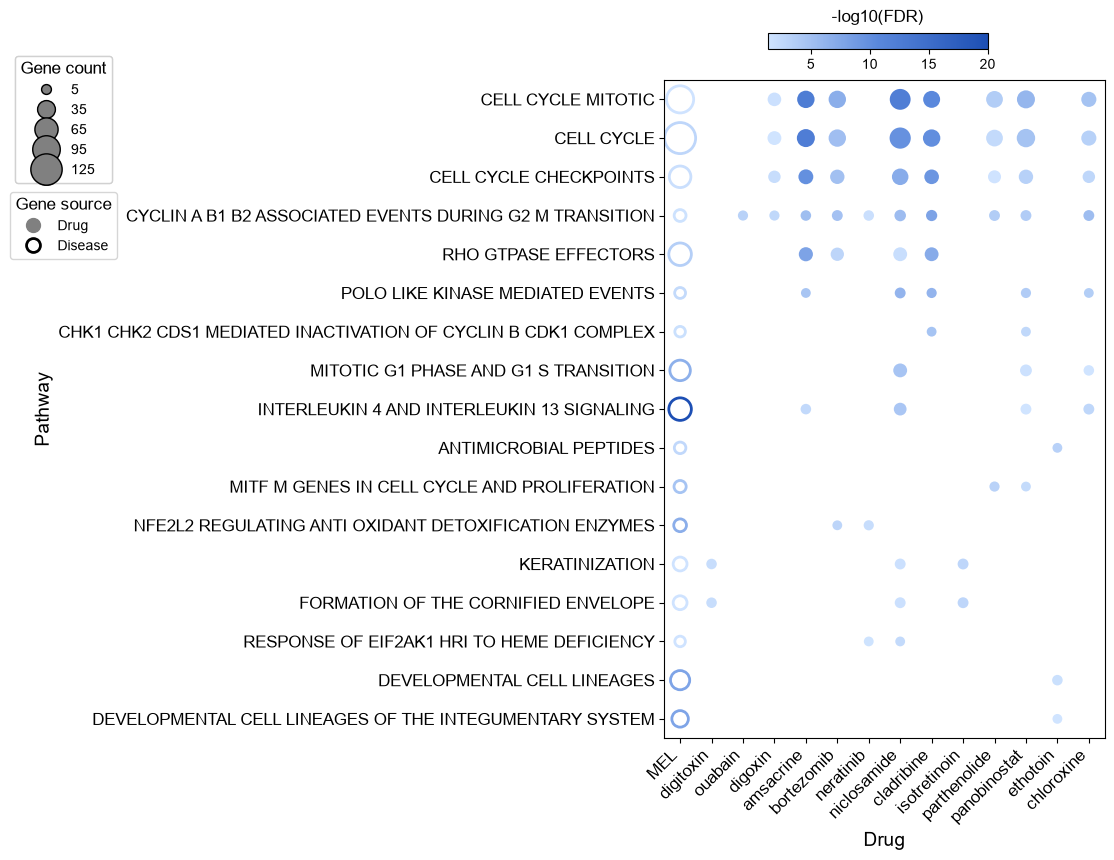

In [ ]:
# Data preparation
drug_plot = drug_pathways.copy()
drug_plot["-log10(FDR)"] = (-np.log10(drug_plot["FDR"])).clip(upper=20)
drug_plot["Gene source"] = "Drug"
drug_plot.loc[drug_plot.Pathway == "REGULATION OF MITF M DEPENDENT GENES INVOLVED IN CELL CYCLE AND PROLIFERATION", "Pathway"] = "MITF M GENES IN CELL CYCLE AND PROLIFERATION"

disease_plot = disease_pathways.copy()
disease_plot["-log10(FDR)"] = (-np.log10(disease_plot["FDR"])).clip(upper=20)
disease_plot["Gene source"] = "Disease"
disease_plot.loc[disease_plot.Pathway == "REGULATION OF MITF M DEPENDENT GENES INVOLVED IN CELL CYCLE AND PROLIFERATION", "Pathway"] = "MITF M GENES IN CELL CYCLE AND PROLIFERATION"

plot_df = pd.concat([drug_plot, disease_plot], ignore_index=True)

# Determine pathway order by significance 
pathway_order = (drug_plot.sort_values(by=["FDR", "Gene count"], ascending=[True, False])["Pathway"].drop_duplicates().tolist())

pathway_cat_type = pd.CategoricalDtype(categories=pathway_order, ordered=True)
plot_df["Pathway"] = plot_df["Pathway"].astype(pathway_cat_type)
drug_plot["Pathway"] = drug_plot["Pathway"].astype(pathway_cat_type)
disease_plot["Pathway"] = disease_plot["Pathway"].astype(pathway_cat_type)

# Numeric y positions that respect the categorical order 
drug_plot["y_pos"] = drug_plot["Pathway"].cat.codes
disease_plot["y_pos"] = disease_plot["Pathway"].cat.codes

# Determine drug order by drug score 
drug_order = ["MEL"] + list(top_drugs[top_drugs.index.isin(drug_plot.Drug)].index)
drug_cat_type = pd.CategoricalDtype(categories=drug_order, ordered=True)
plot_df["Drug"] = plot_df["Drug"].astype(drug_cat_type)
drug_plot["Drug"] = drug_plot["Drug"].astype(drug_cat_type)
disease_plot["Drug"] = disease_plot["Drug"].astype(drug_cat_type)

# Numeric x positions that respect the categorical order
drug_plot["x_pos"] = drug_plot["Drug"].cat.codes
disease_plot["x_pos"] = disease_plot["Drug"].cat.codes

custom_colors = LinearSegmentedColormap.from_list(
    "custom",
    [
        "#d0e4ff",  # very light blue       "#ffdcd2" very light red 
        "#5a88dc",  # medium blue           "#ec5e3a" medium red    
        "#1d4fb4",  # dark blue             "#8f2d1e" dark red 
    ]
)

plt.rcParams["font.family"] = "Arial"

# Shared scales
norm = Normalize(vmin=plot_df["-log10(FDR)"].min(), vmax=plot_df["-log10(FDR)"].max())
gc_min, gc_max = plot_df["Gene count"].min(), plot_df["Gene count"].max()

def size_scale(vals):
    return 50 + (np.asarray(vals) - gc_min) / (gc_max - gc_min) * (500 - 50)

fig, ax = plt.subplots(figsize=(11, 8))

# Drug bubbles (filled) 
ax.scatter(
    drug_plot["x_pos"], drug_plot["y_pos"],
    s=size_scale(drug_plot["Gene count"]),
    c=drug_plot["-log10(FDR)"], cmap=custom_colors, norm=norm,
    edgecolors="none",
)

# Disease bubbles (empty)
disease_colors = custom_colors(norm(disease_plot["-log10(FDR)"]))
ax.scatter(
    disease_plot["x_pos"], disease_plot["y_pos"],
    s=size_scale(disease_plot["Gene count"]),
    facecolors="none",
    edgecolors=disease_colors,
    linewidths=2,
)

# x-axis
ax.set_xticks(range(len(drug_order)))
ax.set_xticklabels(drug_order, fontsize=12, rotation=45, ha="right")
ax.set_xlim(-0.5, len(drug_order) - 0.5)

# y-axis
ax.set_yticks(range(len(pathway_order)))
ax.set_yticklabels(pathway_order, fontsize=12)
ax.set_ylim(-0.5, len(pathway_order) - 0.5)
ax.invert_yaxis()

ax.set_ylabel("Pathway", fontsize=14)
ax.set_xlabel("Drug", fontsize=14)

# Manual size legend
size_values = np.linspace(gc_min, gc_max, 5)  # 5 values 
size_values = np.unique((np.round(size_values / 5) * 5).astype(int)) 
size_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='black', markersize=np.sqrt(size_scale(v)), label=str(v))
    for v in size_values
]

# Manual color legend (colorbar) 
sm = plt.cm.ScalarMappable(cmap=custom_colors, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.68, 1.02, 0.2, 0.02])  
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.ax.xaxis.set_label_position("top")
cbar.ax.set_xlabel("-log10(FDR)", fontsize=12, labelpad=8)
cbar.ax.tick_params(labelsize=10)

# Type legend (filled vs empty) 
type_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor="gray",
           markeredgecolor="gray", markersize=10, label='Drug'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor="#000000", markeredgewidth=2, markersize=10, label='Disease'),  
]

# First legend 
size_legend = fig.legend(
    handles=size_handles, 
    title="Gene count",
    fontsize=10,
    title_fontsize=12,
    loc="upper center",
    bbox_to_anchor=(0.04,1.02),
    ncol=1,
)

fig.add_artist(size_legend)

# Second legend
fig.legend(
    handles=type_handles,
    title="Gene source",
    fontsize=10,
    title_fontsize=12,
    loc="upper center",
    bbox_to_anchor=(0.04, 0.85),  
    ncol=1,
)

plt.tight_layout()
# plt.savefig(os.path.join(out_path, "MEL_enrichment.png"), dpi=300, bbox_inches="tight")
plt.show()